In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import clear_output
import time

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.metrics import (f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report)
import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.optimizers import Adam
import keras

In [13]:
df = pd.read_csv('features_day2.csv', index_col='DateTime', parse_dates=True)

feature_cols = [col for col in df.columns if col != 'outage']
X = df[feature_cols]
y = df['outage']

print(f"✅ Loaded!")
print(f"   Shape    : {X.shape}")
print(f"   Features : {len(feature_cols)}")
print(f"   Outage % : {y.mean()*100:.3f}%")

✅ Loaded!
   Shape    : (52416, 30)
   Features : 30
   Outage % : 0.727%


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"  Train : {X_train.shape[0]:,} rows")
print(f"  Test  : {X_test.shape[0]:,} rows")

X_maj = X_train[y_train == 0]
y_maj = y_train[y_train == 0]
X_min = X_train[y_train == 1]
y_min = y_train[y_train == 1]

print(f"  Before → Normal: {len(X_maj):,} | Outage: {len(X_min):,}")

X_min_up, y_min_up = resample(
    X_min, y_min,
    replace=True, n_samples=len(X_maj), random_state=42
)

X_train_bal = pd.concat([X_maj, X_min_up]).sample(frac=1, random_state=42).reset_index(drop=True)
y_train_bal = pd.concat([y_maj, y_min_up]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"  After  → Normal: {(y_train_bal==0).sum():,} | Outage: {(y_train_bal==1).sum():,}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train_bal,
    test_size=0.15, random_state=42
)

print(f"  Train set  : {X_tr.shape[0]:,} rows")
print(f"  Val set    : {X_val.shape[0]:,} rows  ← watched every epoch")
print(f"  Test set   : {X_test_scaled.shape[0]:,} rows  ← final evaluation only")

joblib.dump(scaler, 'scaler.pkl')
print(f"\nInput size for Neural Network : {X_tr.shape[1]} features")

  Train : 41,932 rows
  Test  : 10,484 rows
  Before → Normal: 41,627 | Outage: 305
  After  → Normal: 41,627 | Outage: 41,627
  Train set  : 70,765 rows
  Val set    : 12,489 rows  ← watched every epoch
  Test set   : 10,484 rows  ← final evaluation only

Input size for Neural Network : 30 features


In [15]:
INPUT_DIM = X_tr.shape[1]

def build_model(learning_rate=0.001, dropout_rate=0.3):
    model = keras.Sequential([

        # ── Input Layer ──────────────────────────────
        layers.Input(shape=(INPUT_DIM,), name='Input'),

        # ── Block 1 ──────────────────────────────────
        layers.Dense(256, name='Dense_1'),
        layers.BatchNormalization(name='BN_1'),
        layers.Activation('relu', name='ReLU_1'),
        layers.Dropout(dropout_rate, name='Dropout_1'),

        # ── Block 2 ──────────────────────────────────
        layers.Dense(128, name='Dense_2'),
        layers.BatchNormalization(name='BN_2'),
        layers.Activation('relu', name='ReLU_2'),
        layers.Dropout(dropout_rate, name='Dropout_2'),

        # ── Block 3 ──────────────────────────────────
        layers.Dense(64, name='Dense_3'),
        layers.BatchNormalization(name='BN_3'),
        layers.Activation('relu', name='ReLU_3'),
        layers.Dropout(dropout_rate * 0.5, name='Dropout_3'),

        # ── Block 4 ──────────────────────────────────
        layers.Dense(32, name='Dense_4'),
        layers.BatchNormalization(name='BN_4'),
        layers.Activation('relu', name='ReLU_4'),

        # ── Output ───────────────────────────────────
        layers.Dense(1, activation='sigmoid', name='Output')
    ])

    model.compile(
        optimizer = Adam(learning_rate=learning_rate),
        loss      = 'binary_crossentropy',
        metrics   = [
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
        ]
    )
    return model

model = build_model()

print("╔══════════════════════════════════════════╗")
print("║        NEURAL NETWORK ARCHITECTURE       ║")
print("╚══════════════════════════════════════════╝")
model.summary()

total_params = model.count_params()
print(f"\n  Total parameters to learn : {total_params:,}")
print(f"  Input features            : {INPUT_DIM}")
print(f"  Output                    : 1 neuron (sigmoid → outage probability)")
print(f"\n  Architecture:")
print(f"    Input({INPUT_DIM}) → Dense(256) → BN → ReLU → Dropout(0.3)")
print(f"           → Dense(128) → BN → ReLU → Dropout(0.3)")
print(f"           → Dense(64)  → BN → ReLU → Dropout(0.15)")
print(f"           → Dense(32)  → BN → ReLU")
print(f"           → Dense(1)   → Sigmoid")
print(f"\n✅ Model built and compiled!")

╔══════════════════════════════════════════╗
║        NEURAL NETWORK ARCHITECTURE       ║
╚══════════════════════════════════════════╝
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Dense_1 (Dense)             (None, 256)               7936      
                                                                 
 BN_1 (BatchNormalization)   (None, 256)               1024      
                                                                 
 ReLU_1 (Activation)         (None, 256)               0         
                                                                 
 Dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 Dense_2 (Dense)             (None, 128)               32896     
                                                                 
 BN_2 (BatchNormalization)   (None, 128)           

In [16]:
# ── Custom callback: prints a rich log every epoch ──────────────────
class LiveEpochLogger(keras.callbacks.Callback):

    def on_train_begin(self, logs=None):
        self.best_val_loss = np.inf
        self.best_val_auc  = 0
        self.best_epoch    = 0
        self.start_time    = time.time()
        self.epoch_times   = []
        print("\n" + "═"*85)
        print(f"{'Epoch':>6} │ {'Loss':>8} │ {'Acc':>7} │ {'AUC':>7} │ "
              f"{'Val Loss':>9} │ {'Val Acc':>8} │ {'Val AUC':>8} │ {'Status'}")
        print("═"*85)

    def on_epoch_begin(self, epoch, logs=None):
        self._epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        epoch_time = time.time() - self._epoch_start
        self.epoch_times.append(epoch_time)

        loss     = logs.get('loss',         0)
        acc      = logs.get('accuracy',     0)
        auc      = logs.get('auc',          0)
        val_loss = logs.get('val_loss',     0)
        val_acc  = logs.get('val_accuracy', 0)
        val_auc  = logs.get('val_auc',      0)

        # Track best
        improved = ''
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.best_val_auc  = val_auc
            self.best_epoch    = epoch + 1
            improved           = '🔥 best!'

        # Loss trend arrow
        if epoch == 0:
            trend = '  '
        elif val_loss < getattr(self, '_prev_val_loss', val_loss):
            trend = '↓ '
        else:
            trend = '↑ '
        self._prev_val_loss = val_loss

        # ETA calculation
        elapsed  = time.time() - self.start_time
        avg_time = elapsed / (epoch + 1)
        total_ep = self.params['epochs']
        remaining = avg_time * (total_ep - epoch - 1)
        eta = f"{int(remaining//60)}m {int(remaining%60)}s"

        print(f"  {epoch+1:>4} │ {loss:>8.4f} │ {acc:>6.2%} │ {auc:>7.4f} │ "
              f"{val_loss:>9.4f} │ {val_acc:>7.2%} │ {val_auc:>8.4f} │ "
              f"{trend}{improved}  ETA: {eta}")

    def on_train_end(self, logs=None):
        total = time.time() - self.start_time
        print("═"*85)
        print(f"\n  🏁 Training complete!")
        print(f"     Total time        : {total/60:.1f} minutes")
        print(f"     Best epoch        : {self.best_epoch}")
        print(f"     Best val loss     : {self.best_val_loss:.4f}")
        print(f"     Best val AUC      : {self.best_val_auc:.4f}")
        print(f"     Avg time/epoch    : {np.mean(self.epoch_times):.1f}s")


# ── Keras built-in callbacks ─────────────────────────────────────────
early_stop = callbacks.EarlyStopping(
    monitor              = 'val_loss',
    patience             = 20,         # wait 20 epochs before stopping
    restore_best_weights = True,
    verbose              = 0           # our custom logger handles printing
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = 0.5,          # halve learning rate when stuck
    patience = 8,
    min_lr   = 1e-6,
    verbose  = 1             # prints when LR is reduced
)

checkpoint = callbacks.ModelCheckpoint(
    filepath          = 'best_model.keras',
    monitor           = 'val_auc',
    mode              = 'max',
    save_best_only    = True,
    verbose           = 0
)

live_logger = LiveEpochLogger()

print("✅ Callbacks configured:")
print("   LiveEpochLogger  → prints loss/acc/auc every epoch")
print("   EarlyStopping    → stops if val_loss doesn't improve for 20 epochs")
print("   ReduceLROnPlateau → halves learning rate if stuck for 8 epochs")
print("   ModelCheckpoint  → saves best model automatically")
print("\n▶  Ready to train! Run Cell 6.")

✅ Callbacks configured:
   LiveEpochLogger  → prints loss/acc/auc every epoch
   EarlyStopping    → stops if val_loss doesn't improve for 20 epochs
   ReduceLROnPlateau → halves learning rate if stuck for 8 epochs
   ModelCheckpoint  → saves best model automatically

▶  Ready to train! Run Cell 6.


In [17]:

print(f"║  Max epochs    : 200                     ║")
print(f"║  Batch size    : 512                     ║")
print(f"║  Early stop    : after 20 bad epochs     ║")
print(f"║  LR reduction  : after 8 bad epochs      ║")
print(f"║  Saving best   : best_model.keras        ║")
BATCH_SIZE = 512
MAX_EPOCHS = 200

history = model.fit(
    X_tr, y_tr,
    epochs          = MAX_EPOCHS,
    batch_size      = BATCH_SIZE,
    validation_data = (X_val, y_val),
    callbacks       = [live_logger, early_stop, reduce_lr, checkpoint],
    verbose         = 0,    # 0 = suppress default Keras logs (our logger handles it)
    shuffle         = True,
    class_weight    = {0: 1.0, 1: 1.0}  # balanced by oversampling already
)


║  Max epochs    : 200                     ║
║  Batch size    : 512                     ║
║  Early stop    : after 20 bad epochs     ║
║  LR reduction  : after 8 bad epochs      ║
║  Saving best   : best_model.keras        ║

═════════════════════════════════════════════════════════════════════════════════════
 Epoch │     Loss │     Acc │     AUC │  Val Loss │  Val Acc │  Val AUC │ Status
═════════════════════════════════════════════════════════════════════════════════════


     1 │   0.1307 │ 95.95% │  0.9940 │    0.0599 │  98.59% │   0.9999 │   🔥 best!  ETA: 17m 15s
     2 │   0.0249 │ 99.47% │  0.9992 │    0.0191 │  99.54% │   0.9998 │ ↓ 🔥 best!  ETA: 11m 25s
     3 │   0.0162 │ 99.62% │  0.9995 │    0.0119 │  99.74% │   0.9996 │ ↓ 🔥 best!  ETA: 9m 20s
     4 │   0.0130 │ 99.67% │  0.9996 │    0.0103 │  99.75% │   0.9997 │ ↓ 🔥 best!  ETA: 8m 22s
     5 │   0.0114 │ 99.71% │  0.9996 │    0.0107 │  99.77% │   0.9990 │ ↑   ETA: 7m 46s
     6 │   0.0100 │ 99.73% │  0.9997 │    0.0082 

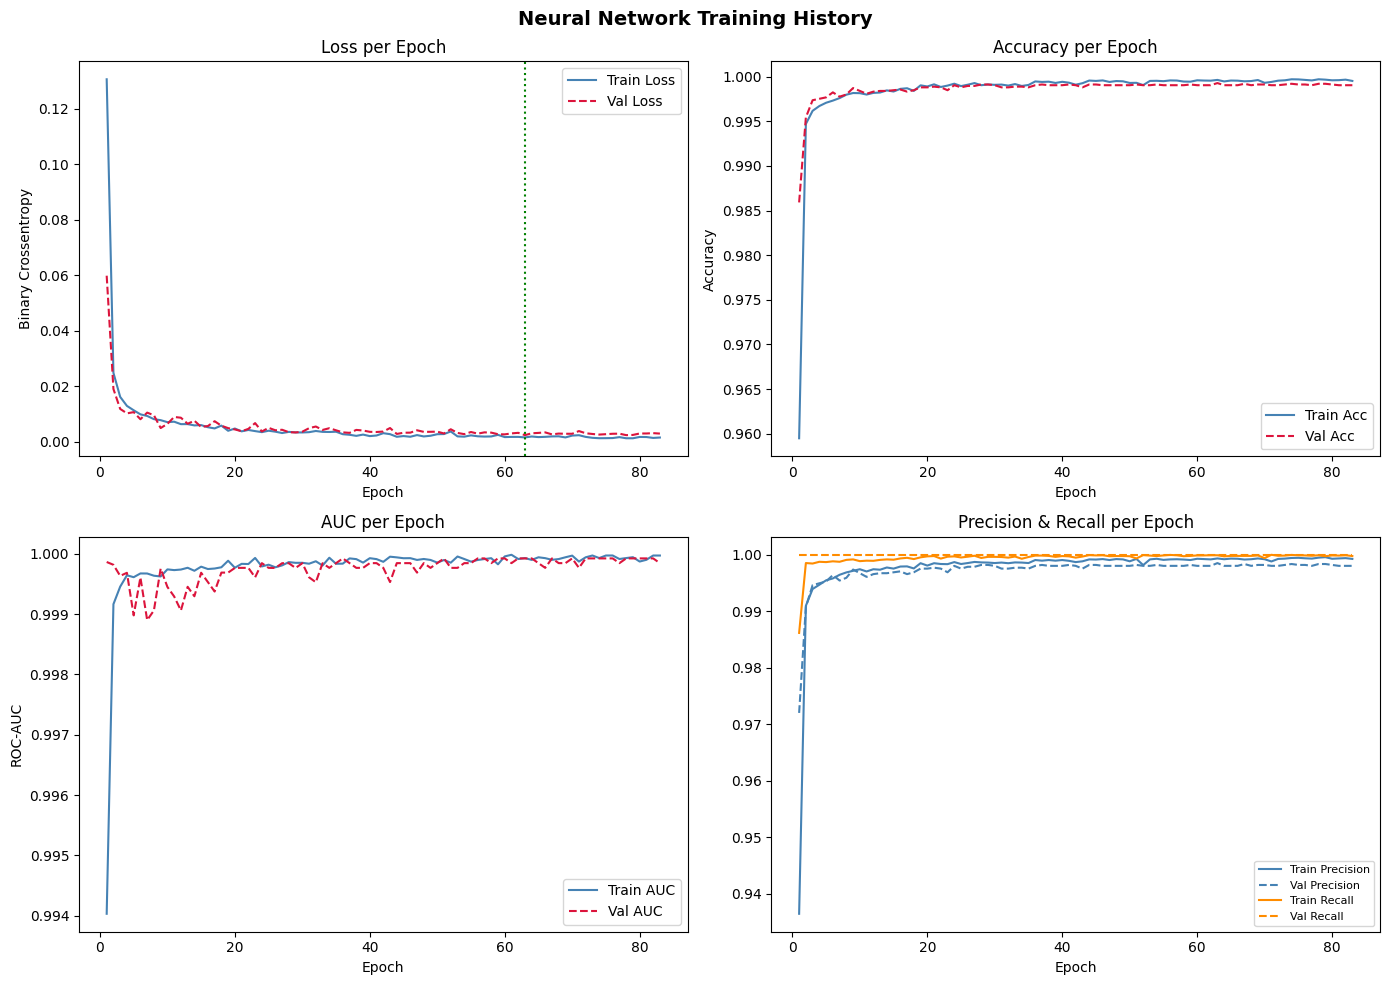

✅ Saved → plot_nn_training_curves.png
   Total epochs ran : 83
   Best epoch       : 63


In [18]:
hist = history.history
epochs_ran = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Neural Network Training History', fontsize=14, fontweight='bold')

# Loss
axes[0,0].plot(epochs_ran, hist['loss'],     label='Train Loss', color='steelblue')
axes[0,0].plot(epochs_ran, hist['val_loss'], label='Val Loss',   color='crimson', linestyle='--')
axes[0,0].set_title('Loss per Epoch')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Binary Crossentropy')
axes[0,0].legend()
axes[0,0].axvline(x=live_logger.best_epoch, color='green', linestyle=':', label=f'Best epoch {live_logger.best_epoch}')

# Accuracy
axes[0,1].plot(epochs_ran, hist['accuracy'],     label='Train Acc', color='steelblue')
axes[0,1].plot(epochs_ran, hist['val_accuracy'], label='Val Acc',   color='crimson', linestyle='--')
axes[0,1].set_title('Accuracy per Epoch')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend()

# AUC
axes[1,0].plot(epochs_ran, hist['auc'],     label='Train AUC', color='steelblue')
axes[1,0].plot(epochs_ran, hist['val_auc'], label='Val AUC',   color='crimson', linestyle='--')
axes[1,0].set_title('AUC per Epoch')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('ROC-AUC')
axes[1,0].legend()

# Precision & Recall
axes[1,1].plot(epochs_ran, hist['precision'],     label='Train Precision', color='steelblue')
axes[1,1].plot(epochs_ran, hist['val_precision'], label='Val Precision',   color='steelblue', linestyle='--')
axes[1,1].plot(epochs_ran, hist['recall'],        label='Train Recall',    color='darkorange')
axes[1,1].plot(epochs_ran, hist['val_recall'],    label='Val Recall',      color='darkorange', linestyle='--')
axes[1,1].set_title('Precision & Recall per Epoch')
axes[1,1].set_xlabel('Epoch')
axes[1,1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('plot_nn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved → plot_nn_training_curves.png")
print(f"   Total epochs ran : {len(epochs_ran)}")
print(f"   Best epoch       : {live_logger.best_epoch}")

╔══════════════════════════════════════════╗
║         FINAL TEST SET EVALUATION        ║
╚══════════════════════════════════════════╝

  Accuracy  : 99.8760%
  F1 Score  : 0.9212
  ROC-AUC   : 0.9999

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     10408
      Outage       0.85      1.00      0.92        76

    accuracy                           1.00     10484
   macro avg       0.93      1.00      0.96     10484
weighted avg       1.00      1.00      1.00     10484



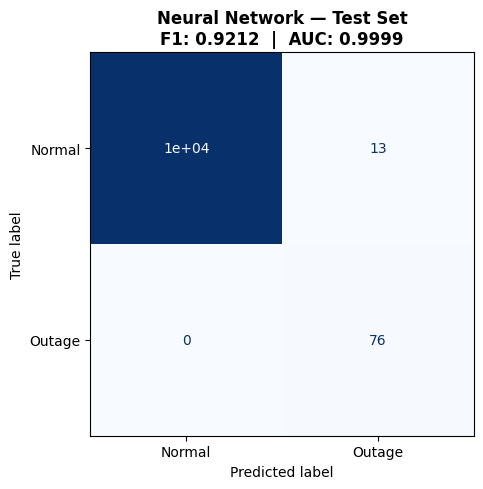

✅ Results saved → nn_results.pkl
▶  Run Cell 6 next — XGBoost with round-by-round logs!


In [19]:
print("╔══════════════════════════════════════════╗")
print("║         FINAL TEST SET EVALUATION        ║")
print("╚══════════════════════════════════════════╝\n")

# Load best saved model
best_model = keras.models.load_model('best_model.keras')

y_prob = best_model.predict(X_test_scaled, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)

f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
acc = (y_pred == y_test.values).mean()

print(f"  Accuracy  : {acc*100:.4f}%")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Normal', 'Outage']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Outage']).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(f'Neural Network — Test Set\nF1: {f1:.4f}  |  AUC: {auc:.4f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_nn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

joblib.dump({'y_test': y_test, 'y_pred': y_pred, 'y_prob': y_prob,
             'f1': f1, 'auc': auc, 'acc': acc}, 'nn_results.pkl')

print("✅ Results saved → nn_results.pkl")
print("▶  Run Cell 6 next — XGBoost with round-by-round logs!")